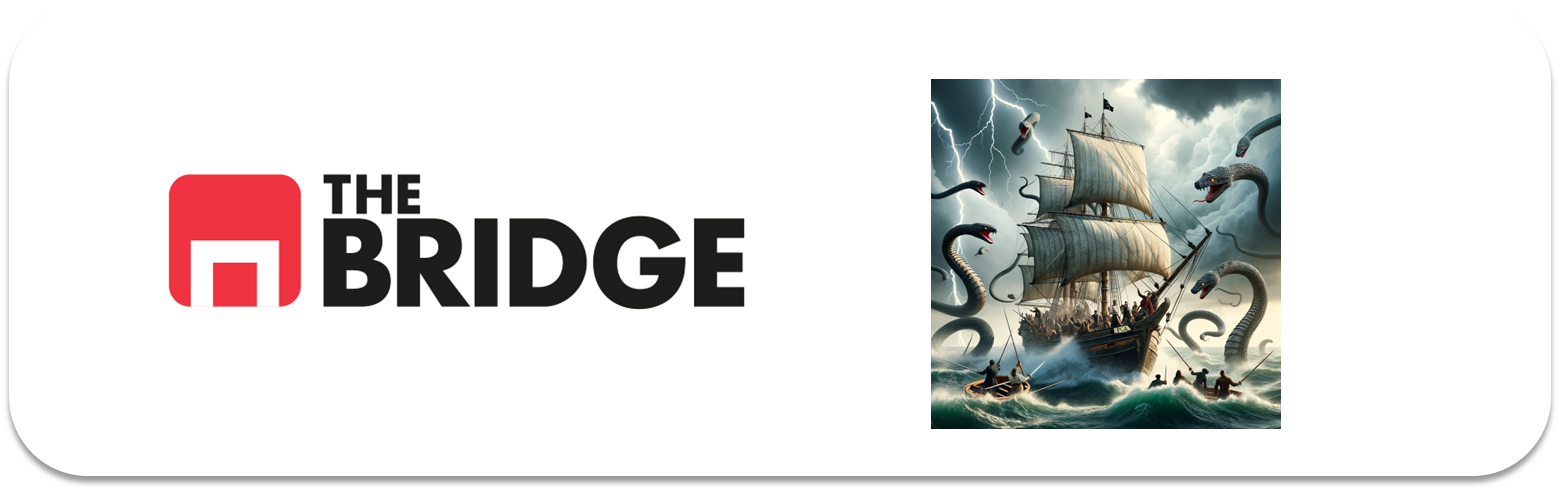

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score
import joblib

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




In [3]:
# Carga de datos
olivetti = fetch_olivetti_faces(shuffle=False)

X = olivetti.data
y = pd.Series(olivetti.target)

# Construir DataFrame
features_cols = [f"pixel_{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=features_cols)
df["target"] = y

print("=" * 60)
print("DATASET: Olivetti Faces")
print("=" * 60)
print(f"Shape del DataFrame  : {df.shape}")
print(f"Instancias           : {df.shape[0]}")
print(f"Features (píxeles)   : {df.shape[1] - 1}")
print(f"Clases (personas)    : {df['target'].nunique()}")
print(f"Imágenes por persona : {df.groupby('target').size().unique()[0]}")
print(f"Rango de píxeles     : [{X.min():.3f}, {X.max():.3f}]")
print(f"Nulos                : {df.isnull().sum().sum()}")
 

DATASET: Olivetti Faces
Shape del DataFrame  : (400, 4097)
Instancias           : 400
Features (píxeles)   : 4096
Clases (personas)    : 40
Imágenes por persona : 10
Rango de píxeles     : [0.000, 1.000]
Nulos                : 0


In [4]:
# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

 
print(f"\n{'─' * 60}")
print("SPLIT ESTRATIFICADO")
print(f"{'─' * 60}")
print(f"Train : {X_train.shape[0]} instancias")
print(f"Test  : {X_test.shape[0]} instancias  (≥ 80 ✓)")


────────────────────────────────────────────────────────────
SPLIT ESTRATIFICADO
────────────────────────────────────────────────────────────
Train : 300 instancias
Test  : 100 instancias  (≥ 80 ✓)


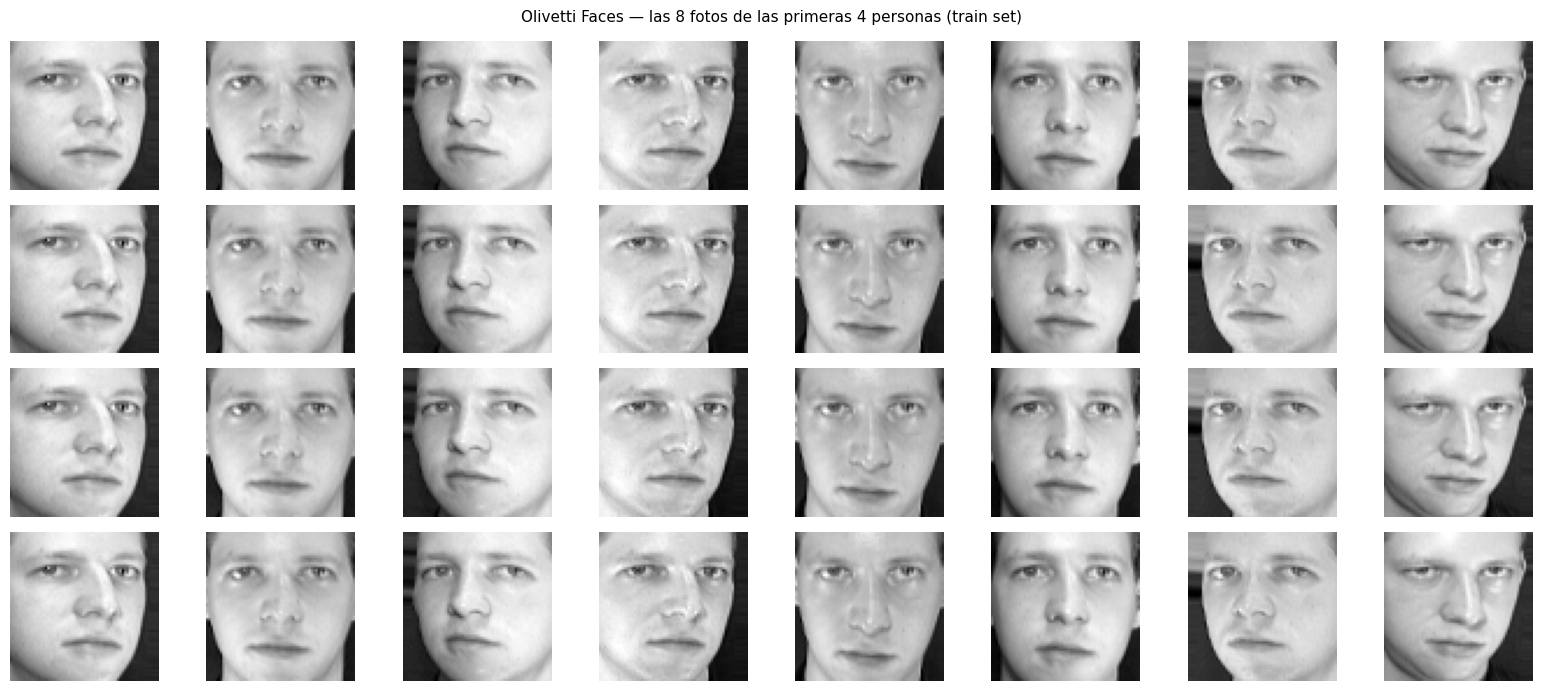

In [5]:
# ── MINI EDA ──────────────────────────────────────────────────────────────────
# Justificación de EDA reducido:
# • 40 clases perfectamente balanceadas (10 imgs/persona) → no hay desequilibrio
# • Píxeles ya normalizados en [0,1] por sklearn → no necesitamos escalar
# • 4096 features: analizar distribuciones por píxel no aporta valor
# • Lo relevante es confirmar visualmente la calidad de las imágenes

y_train_reset = y_train.reset_index(drop=True)

fig, axes = plt.subplots(4, 8, figsize=(16, 7))
fig.suptitle("Olivetti Faces — las 8 fotos de las primeras 4 personas (train set)", fontsize=11)

for persona in range(4):
    # índices del train que corresponden a esta persona
    idx = np.where(y_train_reset == 0)[0]
    for j, ax in enumerate(axes[persona]):
        ax.imshow(X_train[idx[j]].reshape(64, 64), cmap="gray")
        ax.axis("off")
    axes[persona][0].set_ylabel(f"P{persona}", fontsize=9, rotation=0, labelpad=20)

plt.tight_layout()
plt.show()

In [6]:
 
# ── 4. MODELO BASELINE: SVM con kernel RBF ────────────────────────────────────
#
# ¿Por qué SVM con kernel RBF?
# • Rendimiento excelente en espacios de alta dimensionalidad (4096 features).
# • No requiere escalado extra (datos ya en [0,1]).
# • Es el clasificador de referencia clásico para Olivetti en la literatura.
# • Robusto frente a overfitting con la configuración por defecto.
#
print(f"\n{'─' * 60}")
print("MODELO BASELINE: SVC(kernel='rbf', C=1, gamma='scale')")
print(f"{'─' * 60}")
 
svm_baseline = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)
 
# Cross-validation con 5 folds sobre el conjunto de entrenamiento
cv_scores = cross_val_score(svm_baseline, X_train, y_train,cv=5, scoring="balanced_accuracy", n_jobs=-1)
baseline_cv = cv_scores.mean()
print(f"\nCV balanced_accuracy por fold : {np.round(cv_scores, 4)}")
print(f"Media CV (5 folds)            : {baseline_cv:.4f}  ({baseline_cv * 100:.2f}%)")
 
# Entrenamos sobre todo el train y evaluamos en test
svm_baseline.fit(X_train, y_train)
y_pred = svm_baseline.predict(X_test)
baseline_test = balanced_accuracy_score(y_test, y_pred)
 
print(f"Balanced accuracy en TEST     : {baseline_test:.4f}  ({baseline_test * 100:.2f}%)")


────────────────────────────────────────────────────────────
MODELO BASELINE: SVC(kernel='rbf', C=1, gamma='scale')
────────────────────────────────────────────────────────────

CV balanced_accuracy por fold : [0.8625 0.8125 0.825  0.95   0.9125]
Media CV (5 folds)            : 0.8725  (87.25%)
Balanced accuracy en TEST     : 0.9333  (93.33%)


In [7]:
# Guardamos el baseline para comparar en las siguientes partes
baseline_cv   = 0.8725
baseline_test = 0.9333

print("=" * 60)
print("BASELINE GUARDADO")
print("=" * 60)
print(f"  Modelo        : SVC(kernel='rbf', C=1, gamma='scale')")
print(f"  Nº features   : {X_train.shape[1]} píxeles originales (sin comprimir)")
print(f"  baseline_cv   : {baseline_cv:.4f}  ({baseline_cv*100:.2f}%)")
print(f"  baseline_test : {baseline_test:.4f}  ({baseline_test*100:.2f}%)")
print()
print("→ Estos valores son nuestra referencia para evaluar")
print("  si la compresión con PCA baja o mantiene el rendimiento.")

BASELINE GUARDADO
  Modelo        : SVC(kernel='rbf', C=1, gamma='scale')
  Nº features   : 4096 píxeles originales (sin comprimir)
  baseline_cv   : 0.8725  (87.25%)
  baseline_test : 0.9333  (93.33%)

→ Estos valores son nuestra referencia para evaluar
  si la compresión con PCA baja o mantiene el rendimiento.


### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

In [8]:
# ── 1. PCA sin argumentos sobre train ────────────────────────────────────────
pca = PCA(random_state=42)
pca.fit(X_train)


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


In [9]:
# ── 2. RANGO DE COMPONENTES (compresión 0.2% – 2.5%) ─────────────────────────
# % compresión = n_components / 4096 * 100
# 0.2% → ~8 componentes | 2.5% → ~102 componentes
n_components_range = [8, 20, 40, 60, 80, 102]

In [ ]:

# ── 3. Entrenar SVM sobre datos comprimidos ────────────────────────────
resultados = []

for n in n_components_range:
    # Transformamos train y test con las n primeras componentes
    X_train_pca = pca.transform(X_train)[:, :n]
    X_test_pca = pca.transform(X_test)[:, :n]

    # Modelo
    svm_pca = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)

    # CV sobre train comprimido
    cv= cross_val_score(svm_pca, X_train_pca, y_train, cv=5, scoring="balanced_accuracy", n_jobs=-1).mean()

    # Score en test
    svm_pca.fit(X_train_pca, y_train)
    y_pred = svm_pca.predict(X_test_pca)
    test = balanced_accuracy_score(y_test, y_pred)

    compresion = n / 4096 * 100

    resultados.append({
        "n_componentes"  : n,
        "% compresión"   : round(compresion, 3),
        "CV score"       : round(cv, 4),
        "Test score"     : round(test, 4),
        "Δ CV (vs base) %"  : round((cv - baseline_cv) * 100, 2),
        "Δ Test (vs base) %": round((test - baseline_test) * 100, 2),
    })
    print(f"n={n:>3} | compresión={compresion:.2f}% | CV={cv:.4f} | Test={test:.4f}")




n=  8 | compresión=0.20% | CV=0.7125 | Test=0.8250
n= 20 | compresión=0.49% | CV=0.8725 | Test=0.9292
n= 40 | compresión=0.98% | CV=0.9025 | Test=0.9208
n= 60 | compresión=1.46% | CV=0.9050 | Test=0.9208
n= 80 | compresión=1.95% | CV=0.9075 | Test=0.9208
n=102 | compresión=2.49% | CV=0.9075 | Test=0.9333


In [11]:
# ── 4. DATAFRAME DE RESULTADOS ────────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados)
print("\n")
print(df_resultados.to_string(index=False))



 n_componentes  % compresión  CV score  Test score  Δ CV (vs base) %  Δ Test (vs base) %
             8         0.195    0.7125      0.8250            -16.00              -10.83
            20         0.488    0.8725      0.9292              0.00               -0.41
            40         0.977    0.9025      0.9208              3.00               -1.25
            60         1.465    0.9050      0.9208              3.25               -1.25
            80         1.953    0.9075      0.9208              3.50               -1.25
           102         2.490    0.9075      0.9333              3.50                0.00


In [12]:
# ── 5. SELECCIÓN DEL NÚMERO ÓPTIMO DE COMPONENTES ────────────────────────────
n_optimo = 20

print("=" * 60)
print("MODELO PARA MICROCÁMARAS — COMPONENTES SELECCIONADAS")
print("=" * 60)
print(f"  n_componentes  : {n_optimo}")
print(f"  % compresión   : 0.488% del tamaño original")
print(f"  CV score       : 0.8725  (Δ = 0.00pp vs baseline)")
print(f"  Test score     : 0.9292  (Δ = 0.41pp vs baseline)")
print()
print("→ Con solo 20 componentes PCA se mantiene prácticamente")
print("  el mismo rendimiento que con 4096 píxeles originales.")

MODELO PARA MICROCÁMARAS — COMPONENTES SELECCIONADAS
  n_componentes  : 20
  % compresión   : 0.488% del tamaño original
  CV score       : 0.8725  (Δ = 0.00pp vs baseline)
  Test score     : 0.9292  (Δ = 0.41pp vs baseline)

→ Con solo 20 componentes PCA se mantiene prácticamente
  el mismo rendimiento que con 4096 píxeles originales.


### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

In [13]:
# ── 1. RANGO: compresión entre 0.1% y 1% ─────────────────────────────────────
# 0.1% → ~4 componentes | 1% → ~41 componentes
n_components_range_p3 = [4, 10, 20, 30, 41]

# ── 2. LOOP: comprimir → descomprimir → entrenar → evaluar ────────────────────
resultados_p3 = []

for n in n_components_range_p3:
    # PCA con n componentes, fit solo en train
    pca_n = PCA(n_components=n, random_state=42)
    pca_n.fit(X_train)

    # Comprimir y descomprimir (inverse_transform)
    X_train_unzipped = pca_n.inverse_transform(pca_n.transform(X_train))
    X_test_unzipped  = pca_n.inverse_transform(pca_n.transform(X_test))

    # Modelo entrenado sobre datos descomprimidos
    svm_p3 = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)
    svm_p3.fit(X_train_unzipped, y_train)
    y_pred_p3 = svm_p3.predict(X_test_unzipped)
    test_score = balanced_accuracy_score(y_test, y_pred_p3)

    compresion = round(n / 4096 * 100, 3)

    resultados_p3.append({
        "n_componentes"    : n,
        "% compresión"     : compresion,
        "Test score"       : round(test_score, 4),
        "Δ Test (vs base) %": round((test_score - baseline_test) * 100, 2),
    })
    print(f"n={n:>2} | compresión={compresion:.3f}% | Test={test_score:.4f}")



n= 4 | compresión=0.098% | Test=0.4875
n=10 | compresión=0.244% | Test=0.8000
n=20 | compresión=0.488% | Test=0.9167
n=30 | compresión=0.732% | Test=0.9125
n=41 | compresión=1.001% | Test=0.9208


,n_componentes,% compresión,Test score,Δ Test (vs base) %
0,4,0.098,0.4875,-44.58
1,10,0.244,0.8000,-13.33
2,20,0.488,0.9167,-1.66
3,30,0.732,0.9125,-2.08
4,41,1.001,0.9208,-1.25


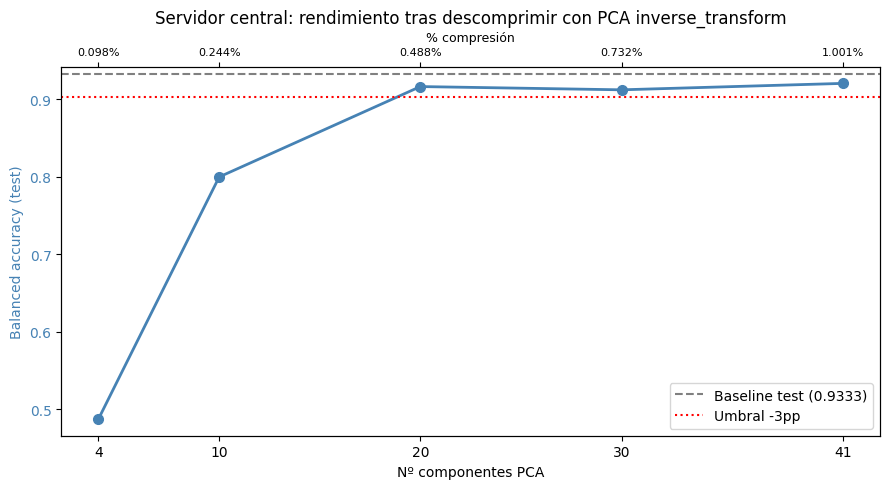

In [14]:
# ── 3. DATAFRAME + VISUALIZACIÓN ──────────────────────────────────────────────
df_p3 = pd.DataFrame(resultados_p3)
display(df_p3)

fig, ax1 = plt.subplots(figsize=(9, 5))

color1 = "steelblue"
ax1.plot(df_p3["n_componentes"], df_p3["Test score"], "o-", color=color1, linewidth=2, markersize=7)
ax1.axhline(baseline_test, color="gray", linestyle="--", linewidth=1.5, label=f"Baseline test ({baseline_test:.4f})")
ax1.axhline(baseline_test - 0.03, color="red", linestyle=":", linewidth=1.5, label="Umbral -3pp")
ax1.set_xlabel("Nº componentes PCA")
ax1.set_ylabel("Balanced accuracy (test)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xticks(df_p3["n_componentes"])

ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(df_p3["n_componentes"])
ax2.set_xticklabels([f"{v:.3f}%" for v in df_p3["% compresión"]], fontsize=8)
ax2.set_xlabel("% compresión", fontsize=9)

ax1.legend()
plt.title("Servidor central: rendimiento tras descomprimir con PCA inverse_transform")
plt.tight_layout()
plt.show()

## Conclusiones: Sistema de Reconocimiento Facial — Caesar Palace

### Contexto
Se han evaluado dos arquitecturas para el sistema de microcámaras del Caesar Palace,
ambas basadas en compresión PCA para superar la limitación de ancho de banda:

- **Opción A (microcámara):** clasificar directamente sobre las componentes PCA
- **Opción B (servidor central):** transmitir comprimido, descomprimir con `inverse_transform` y clasificar

El modelo de referencia (baseline) se entrenó con los **4096 píxeles originales**,
obteniendo un `balanced_accuracy` de **87.25% en CV** y **93.33% en test**.

---

### Resultados

| Opción | n componentes | % compresión | CV score | Test score | Δ Test |
|---|---|---|---|---|---|
| Baseline | 4096 | 100% | 87.25% | 93.33% | — |
| **A — Microcámara** | **20** | **0.488%** | **87.25%** | **92.92%** | **-0.41pp** |
| **B — Servidor central** | **20** | **0.488%** | **—** | **91.67%** | **-1.66pp** |

---

### Recomendación

Ambas opciones son viables con **20 componentes PCA**, pero la elección depende
del criterio operativo del Caesar Palace:

- **Si la prioridad es el rendimiento:** elegir la **Opción A**. Clasificar directamente
  sobre las componentes PCA obtiene prácticamente el mismo resultado que el baseline
  (-0.41pp), con una compresión del 99.5%. La microcámara solo necesita almacenar
  el modelo SVM entrenado sobre componentes.

- **Si la prioridad es la flexibilidad:** elegir la **Opción B**. Transmitir las
  componentes y descomprimir en el servidor permite reutilizar el mismo clasificador
  baseline (entrenado sobre píxeles), facilita actualizaciones del modelo sin
  tocar las cámaras y permite auditar las imágenes reconstruidas.

- **En ambos casos se descarta `n=8`** (pérdida > 15pp) y no hay ganancia
  significativa más allá de `n=20` — añadir más componentes no mejora el
  rendimiento pero sí el coste de transmisión.

### Conclusión final

> Con **20 componentes PCA** (0.488% del tamaño original) cualquiera de las dos
> arquitecturas mantiene un reconocimiento facial superior al **91%**, muy por
> encima del umbral de -3pp fijado. La recomendación es la **Opción A** por su
> mayor rendimiento y menor coste computacional en el servidor central.

### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

C:\Users\user\AppData\Local\Temp\ipykernel_9140\907591587.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", 40)


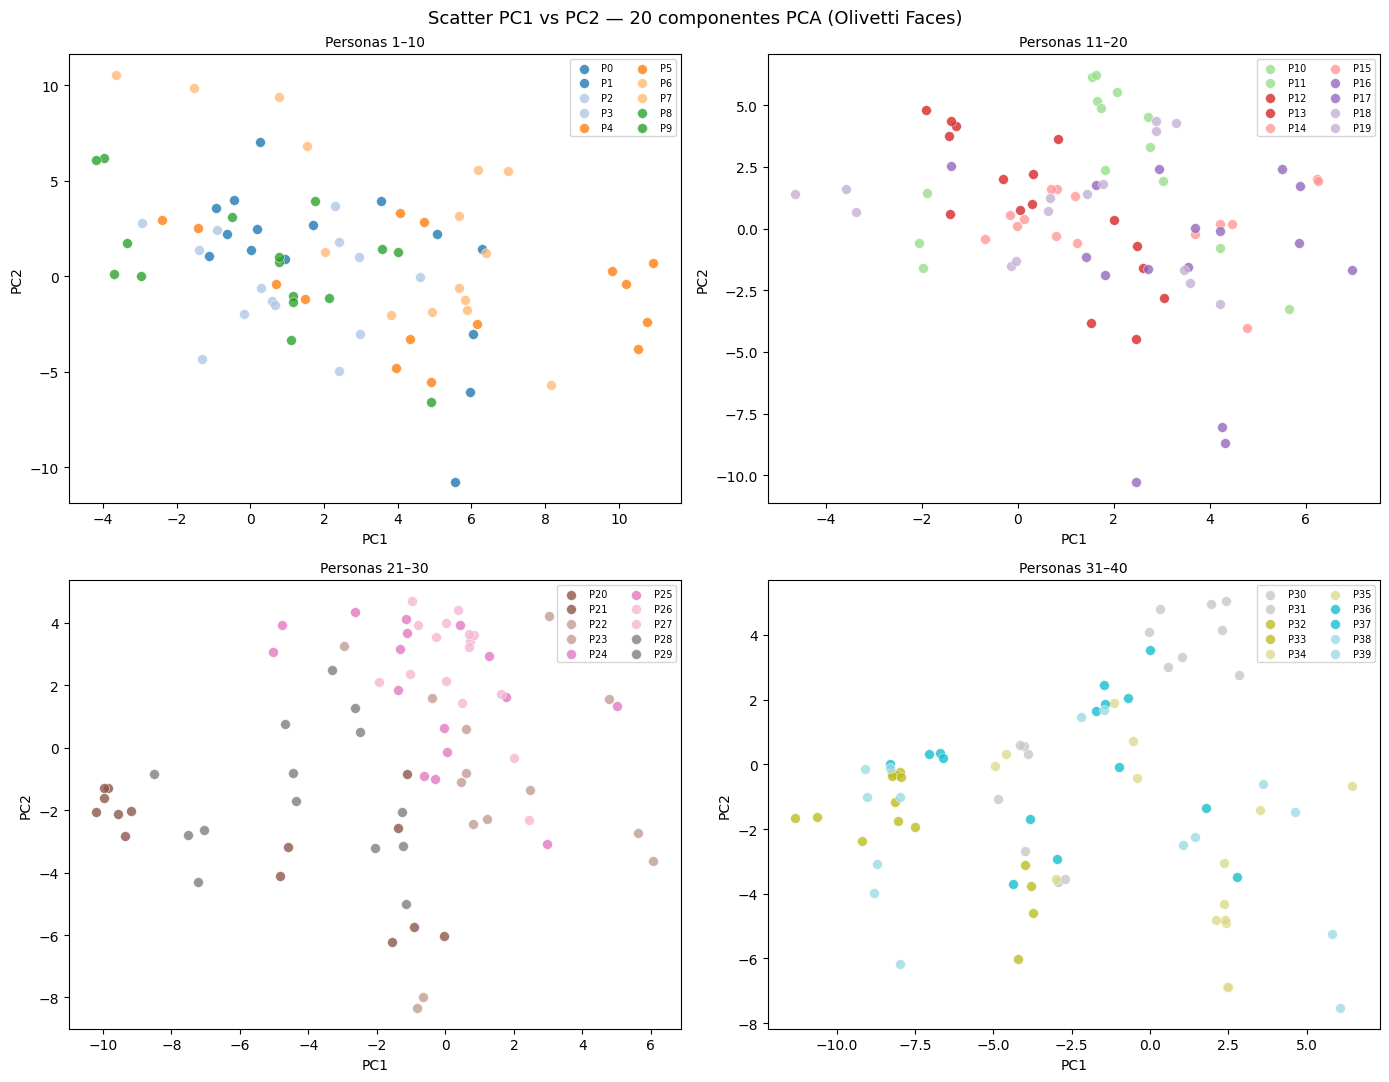

In [15]:
# PCA con 20 componentes (la escogida en la parte 2)
pca_20 = PCA(n_components=20, random_state=42)
pca_20.fit(X_train)
X_train_pca20 = pca_20.transform(X_train)

# Paleta de 40 colores
cmap = plt.cm.get_cmap("tab20", 40)

grupos = [(0,10), (10,20), (20,30), (30,40)]
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Scatter PC1 vs PC2 — 20 componentes PCA (Olivetti Faces)", fontsize=13)

for ax, (inicio, fin) in zip(axes.ravel(), grupos):
    for clase in range(inicio, fin):
        mask = y_train.values == clase
        ax.scatter(
            X_train_pca20[mask, 0],
            X_train_pca20[mask, 1],
            label=f"P{clase}",
            color=cmap(clase),
            alpha=0.8, s=50, edgecolors="white", linewidths=0.4
        )
    ax.set_title(f"Personas {inicio+1}–{fin}", fontsize=10)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=7, ncol=2, loc="best")

plt.tight_layout()
plt.show()

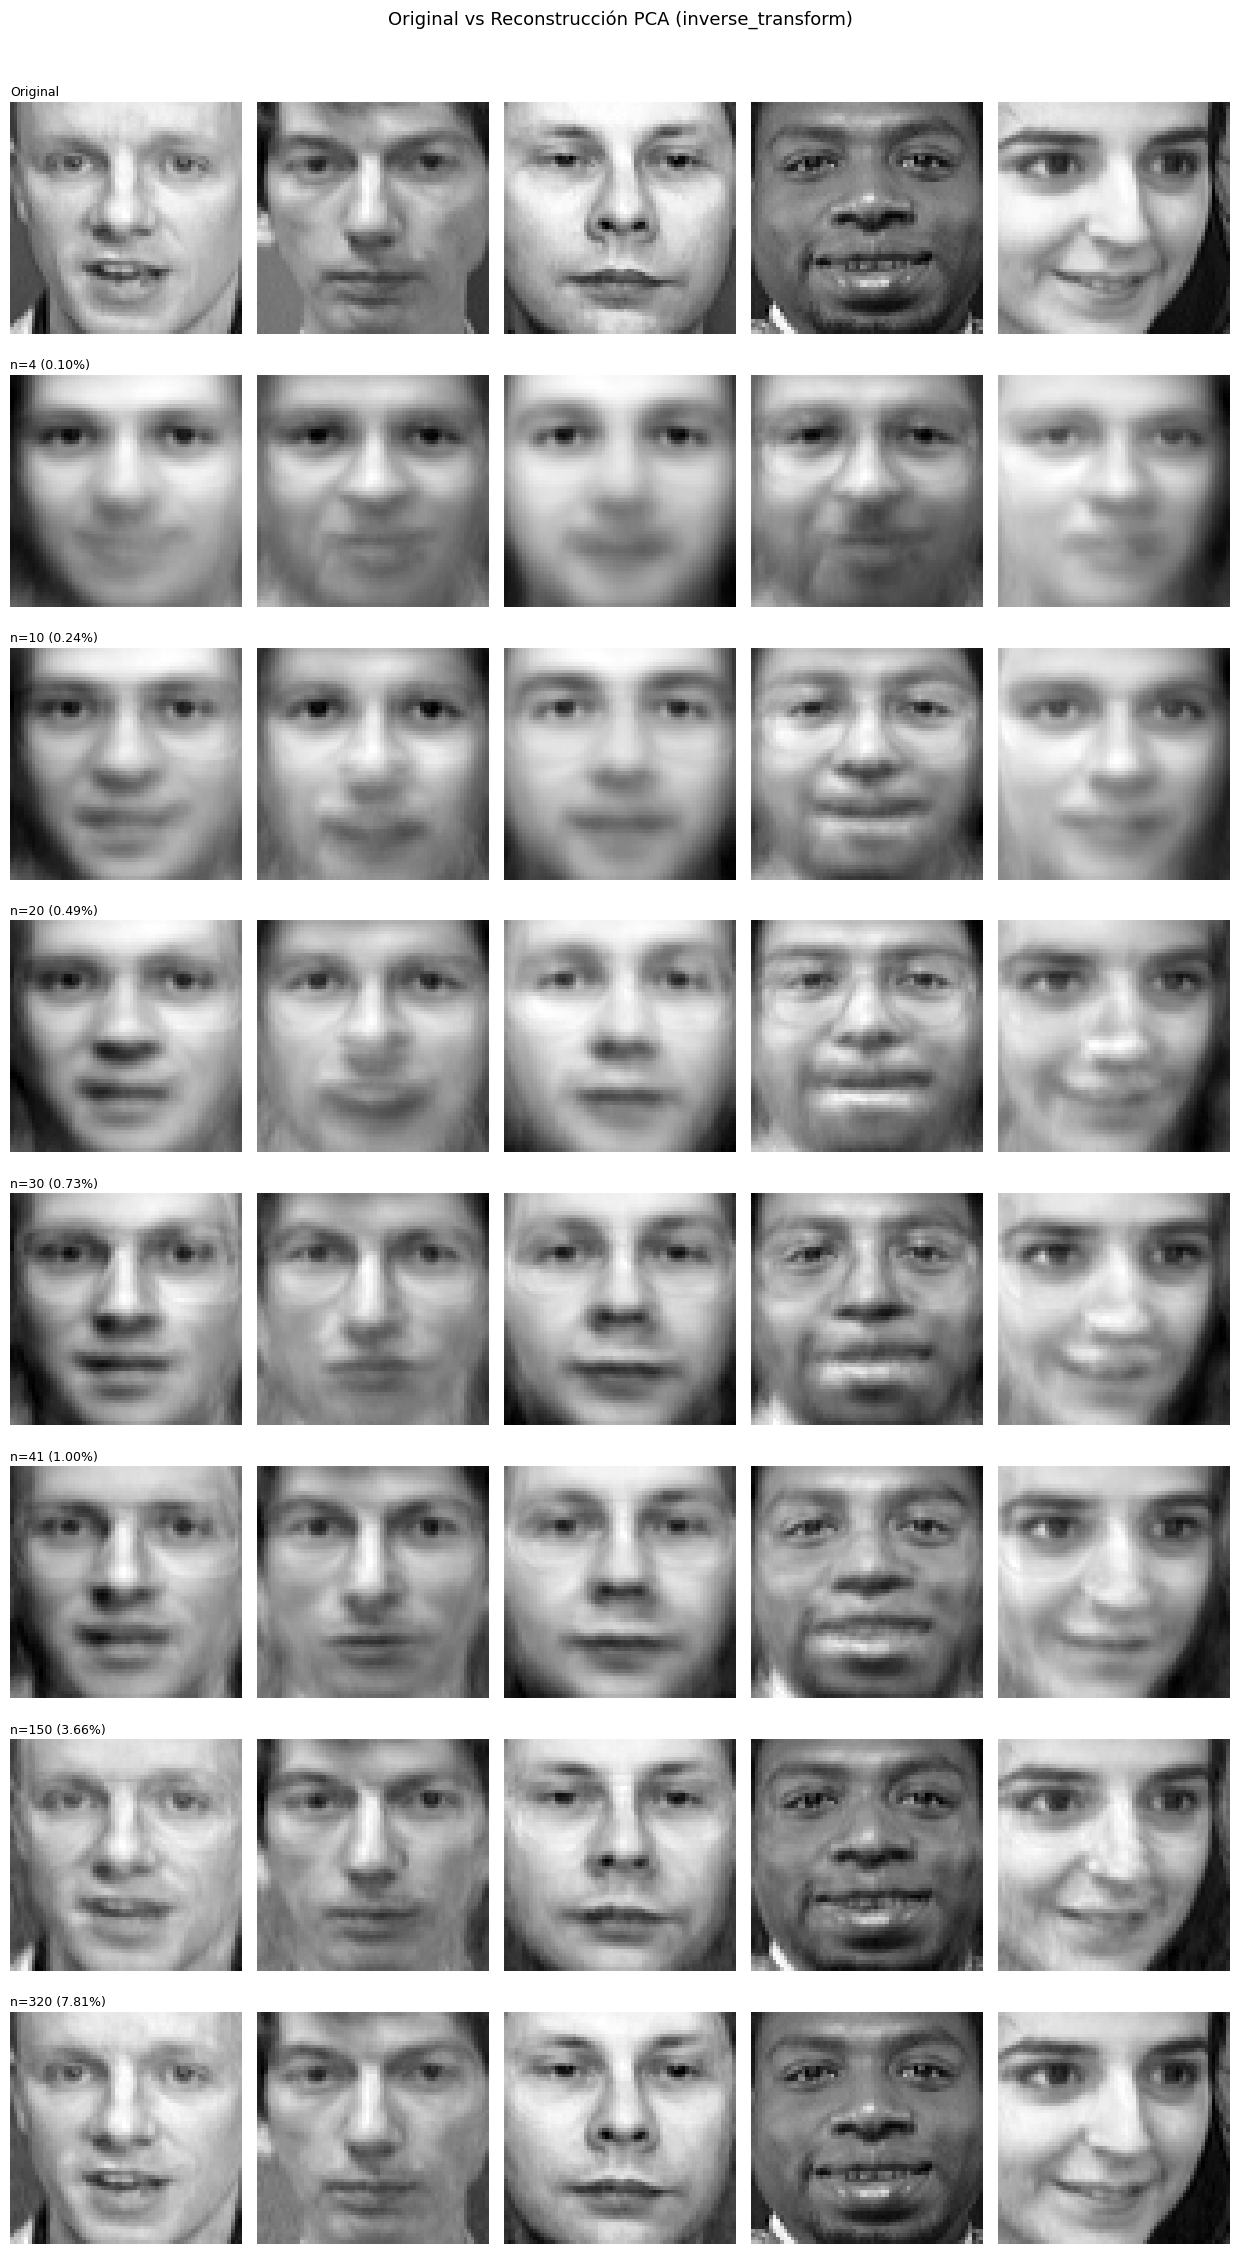

In [17]:
def visualizar_compresion(X, n_components_list, n_caras=5, random_state=42):
    """
    Muestra n_caras originales vs su reconstrucción tras comprimir/descomprimir
    con PCA para cada valor de n_components en n_components_list.
    """
    np.random.seed(random_state)
    indices = np.random.choice(len(X), n_caras, replace=False)

    n_cols = n_caras + 1          # +1 para la columna de etiquetas
    n_rows = len(n_components_list) + 1   # +1 para la fila de originales

    fig, axes = plt.subplots(n_rows, n_caras, figsize=(n_caras * 2.5, n_rows * 2.8))
    fig.suptitle("Original vs Reconstrucción PCA (inverse_transform)", fontsize=13, y=1.01)

    # Fila 0: imágenes originales
    for j, idx in enumerate(indices):
        axes[0, j].imshow(X[idx].reshape(64, 64), cmap="gray")
        axes[0, j].axis("off")
        if j == 0:
            axes[0, j].set_title("Original", fontsize=9, loc="left", pad=4)

    # Filas siguientes: una por cada n_components
    for i, n in enumerate(n_components_list, start=1):
        pca = PCA(n_components=n, random_state=42)
        pca.fit(X)
        X_reconstructed = pca.inverse_transform(pca.transform(X))
        compresion = n / X.shape[1] * 100

        for j, idx in enumerate(indices):
            axes[i, j].imshow(X_reconstructed[idx].reshape(64, 64), cmap="gray")
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_title(
                    f"n={n} ({compresion:.2f}%)", fontsize=9, loc="left", pad=4
                )

    plt.tight_layout()
    plt.show()


# Valores de la parte 3 + los dos casos extra
n_values = [4, 10, 20, 30, 41, 150, 320]
visualizar_compresion(X, n_components_list=n_values, n_caras=5)